In [30]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision import models
from torchvision.models import vit_b_16
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [32]:
# Minority class (label = 1)
minority_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),  # reduced
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Majority class (label = 0)
majority_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [33]:
class ImbalancedDataset:
    def __init__(self, root):
        self.dataset = ImageFolder(root=root)
        self.classes = self.dataset.classes

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, label = self.dataset[idx]

        if label == 1:
            img = minority_transform(img)
        else:
            img = majority_transform(img)

        return img, label

In [34]:
train_dataset = ImbalancedDataset('archive/train')

base_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_dataset = ImageFolder('archive/valid', transform=base_transform)
test_dataset = ImageFolder('archive/test', transform=base_transform)

print("Classes:", train_dataset.classes)

Classes: ['0', '1']


In [35]:
from torch.utils.data import WeightedRandomSampler
import numpy as np

labels = [label for _, label in train_dataset.dataset.samples]

class_counts = np.bincount(labels)
weights = 1. / class_counts
sample_weights = [weights[label] for label in labels]

sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

In [36]:
train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

# transformer (vit)

In [37]:
def build_vit(num_classes):
    model = vit_b_16(weights="IMAGENET1K_V1")

    #freeze all layers
    for param in model.parameters():
        param.requires_grad = False

    #replace classification head
    model.heads.head = nn.Linear(
        model.heads.head.in_features,
        num_classes
    )

    # Unfreeze last transformer block
    for param in model.encoder.layers[-1].parameters():
        param.requires_grad = True

    return model

In [38]:
def train_model(model, train_loader, val_loader, epochs, lr):

    model = model.to(device)
    class_weights = torch.tensor([1/1569, 1/803]).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}")

        validate(model, val_loader)

# validate n eval

In [39]:
def validate(model, val_loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = correct / total
    print("Validation Accuracy:", acc)

In [40]:
def test_model(model, test_loader):

    model.eval()

    y_true = []
    y_pred = []
    y_prob = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)

            y_true.extend(labels.numpy())
            y_pred.extend(predicted.cpu().numpy())
            y_prob.extend(probs[:,1].cpu().numpy())

    print("\nClassification Report")
    print(classification_report(y_true, y_pred))
    cm = confusion_matrix(y_true, y_pred)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

    try:
        auc = roc_auc_score(y_true, y_prob)
        print("ROC AUC:", auc)
    except:
        pass

# run vit

Epoch 1/10 - Loss: 0.6296
Validation Accuracy: 0.35703703703703704
Epoch 2/10 - Loss: 0.5997
Validation Accuracy: 0.4266666666666667
Epoch 3/10 - Loss: 0.5721
Validation Accuracy: 0.49925925925925924
Epoch 4/10 - Loss: 0.5335
Validation Accuracy: 0.5422222222222223
Epoch 5/10 - Loss: 0.5088
Validation Accuracy: 0.5407407407407407
Epoch 6/10 - Loss: 0.4786
Validation Accuracy: 0.5585185185185185
Epoch 7/10 - Loss: 0.4580
Validation Accuracy: 0.5851851851851851
Epoch 8/10 - Loss: 0.4103
Validation Accuracy: 0.5525925925925926
Epoch 9/10 - Loss: 0.3709
Validation Accuracy: 0.5688888888888889
Epoch 10/10 - Loss: 0.3498
Validation Accuracy: 0.5955555555555555

Classification Report
              precision    recall  f1-score   support

           0       0.68      0.59      0.63       208
           1       0.45      0.55      0.50       128

    accuracy                           0.57       336
   macro avg       0.57      0.57      0.56       336
weighted avg       0.59      0.57      0.5

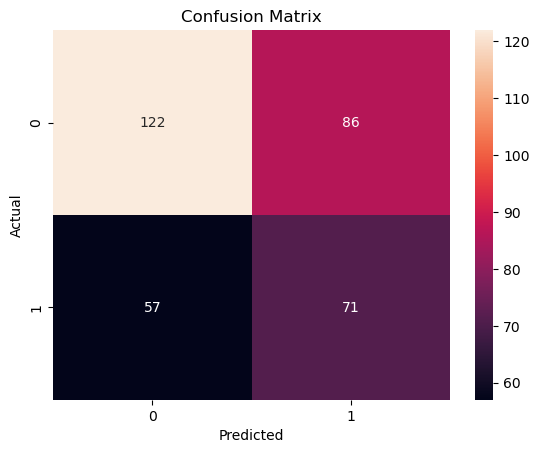

ROC AUC: 0.6438551682692307


In [41]:
model_vit = build_vit(num_classes)

train_model(
    model=model_vit,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=10,
    lr=3e-5
)

test_model(model_vit, test_loader)